# **SECTION 1 FORWARD MODEL: USING THE DIMENSIONLESS CARTESIAN PDE**

**The governing cartesian Partial Differential Equation for the Diffusivity equation**

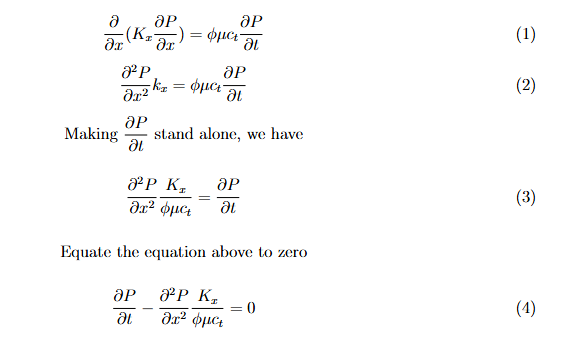

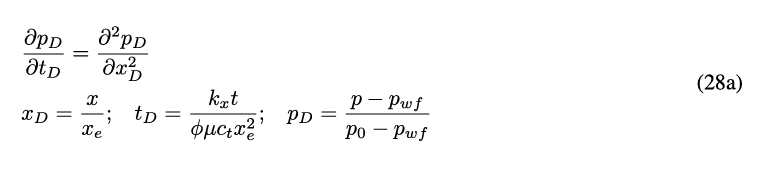


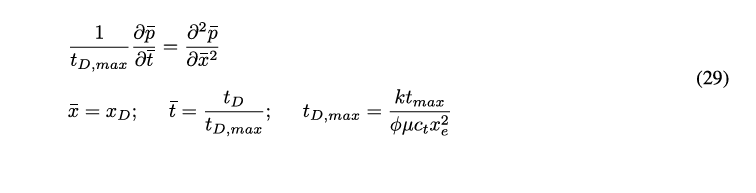

In [4]:
import deepxde as dde
import torch
import numpy as np
import matplotlib.pyplot as plt
dde.backend.backend_name = "pytorch"

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


**Defining the Reservoir, fluid properties and initial setup**

In [2]:
k_md = 120.0
t_max = 30.0
phi = 0.2
mu = 1
ct = 1e-5
x_e = 500.0
C = 0.000588
eta = C * (k_md / (phi * mu * ct)) # The hydraulic diffusivity equation

p_i = 25.0
p_wf = 3.0


tD_max = (eta * t_max) / (x_e**2)

## **CASE 1.1: INVOLVING ONE NO FLOW BOUNDARY**

**Setting up the Domain**

In [2]:
geom_1_1 = dde.geometry.Interval(0.0, 1.0)
timedomain = dde.geometry.TimeDomain(0.0, 1.0)
geomtime_1_1 = dde.geometry.GeometryXTime(geom_1_1, timedomain)

**The governing dimensionless 1D cartesian PDE**

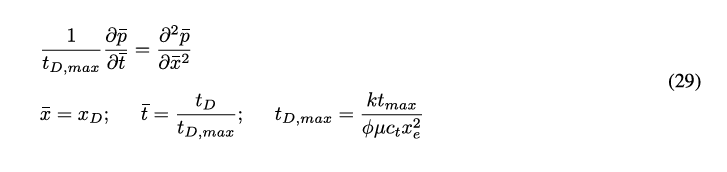

**Setting up the dimensionless cartesian PDE from equation 29**

In [4]:
def pde_dimensionless(x, pD):
    dpD_dt_tilde = dde.grad.jacobian(pD, x, i=0, j=1)
    d2pD_dx_tilde2 = dde.grad.hessian(pD, x, i=0, j=0)
    residual = (1.0 / tD_max) * dpD_dt_tilde - d2pD_dx_tilde2
    return residual

**Setting up the initial and Boundary condition**

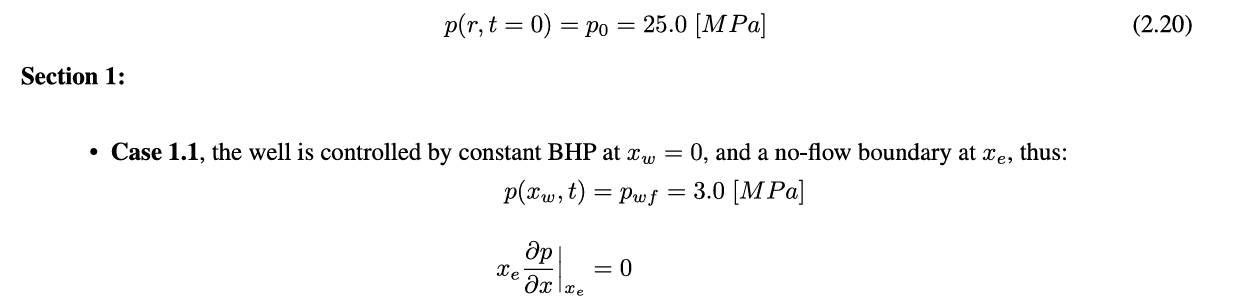

In [5]:
def initial_condition(x):
    return np.ones((len(x), 1))

def pD_wf_func(x):
    return np.zeros((len(x), 1))

def no_flow_residual(x, pD, _):
    dpD_dx_tilde = dde.grad.jacobian(pD, x, i=0, j=0)
    return dpD_dx_tilde

def well_boundary(x, on_boundary):
    return on_boundary and np.isclose(x[0], 0.0)

def no_flow_boundary(x, on_boundary):
    return on_boundary and np.isclose(x[0], 1.0)

ic = dde.icbc.IC(geomtime_1_1, initial_condition, lambda _, on_initial: on_initial)
bc_well = dde.icbc.DirichletBC(geomtime_1_1, pD_wf_func, well_boundary)
bc_noflow = dde.icbc.OperatorBC(geomtime_1_1, no_flow_residual, no_flow_boundary)

**Data Object setup using TimePDE, Model Definition and Model Training**

In [6]:
data_case_1_1 = dde.data.TimePDE(
    geomtime_1_1,
    pde_dimensionless,
    [ic, bc_well, bc_noflow],
    num_domain=8000,
    num_boundary=2000,
    num_initial=2000
)

net = dde.nn.FNN([2] + [32] * 4 + [1], "tanh", "Glorot normal")
model = dde.Model(data_case_1_1, net)

loss_weights = [1.0, 2.0, 2.0, 1.0]

print("Adam Optimization")
model.compile("adam", lr=1e-3, loss_weights=loss_weights)
losshistory, train_state = model.train(iterations=15000)

print("L-BFGS Optimization")
model.compile("L-BFGS")
losshistory, train_state = model.train()

Adam Optimization
Compiling model...
'compile' took 0.958057 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [2.05e-02, 1.40e+00, 2.87e-02, 6.88e-02]    [2.05e-02, 1.40e+00, 2.87e-02, 6.88e-02]    []  
1000      [2.84e-03, 5.64e-03, 1.26e-02, 1.62e-03]    [2.84e-03, 5.64e-03, 1.26e-02, 1.62e-03]    []  
2000      [1.82e-03, 3.38e-03, 9.58e-03, 3.54e-04]    [1.82e-03, 3.38e-03, 9.58e-03, 3.54e-04]    []  
3000      [2.14e-03, 2.30e-03, 8.23e-03, 4.62e-05]    [2.14e-03, 2.30e-03, 8.23e-03, 4.62e-05]    []  
4000      [3.19e-03, 2.35e-03, 7.33e-03, 6.10e-05]    [3.19e-03, 2.35e-03, 7.33e-03, 6.10e-05]    []  
5000      [4.28e-03, 2.32e-03, 6.62e-03, 7.51e-05]    [4.28e-03, 2.32e-03, 6.62e-03, 7.51e-05]    []  
6000      [1.49e-03, 2.03e-03, 6.27e-03, 7.66e-05]    [1.49e-03, 2.03e-03, 6.27e-03, 7.66e-05]    []  
7000      [1.59e-03, 1.90e-03, 6.01e-03, 7.00e-05]    [1.59e-03, 1.90e-03, 6.01e-03, 7

**Pressure visualization Plot**

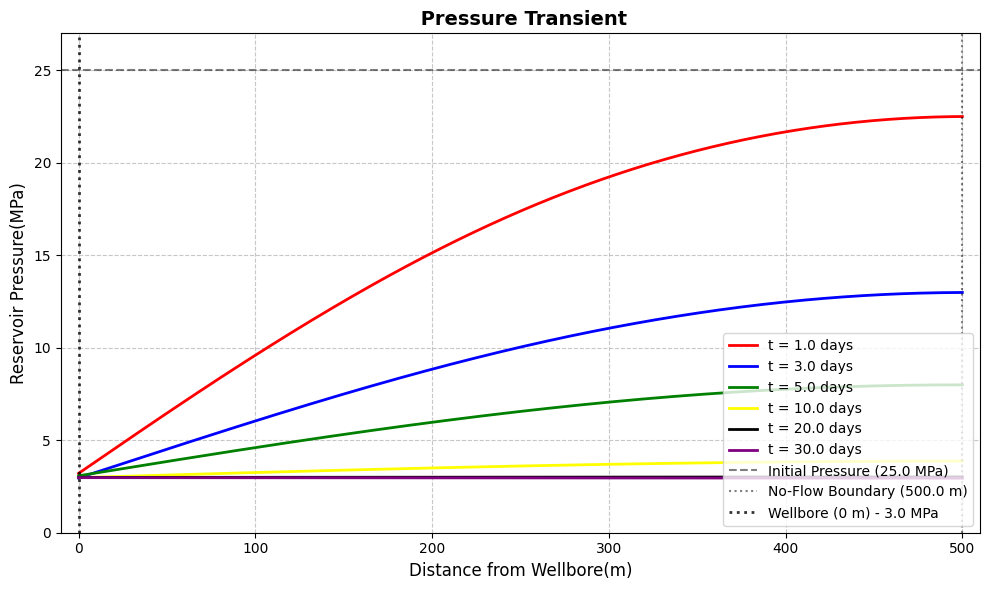

In [ ]:
plt.figure(figsize=(10, 6))
x_real_grid = np.linspace(0, x_e, 500).reshape(-1, 1)
x_tilde_grid = x_real_grid / x_e
time_steps_physical_days = [1.0, 3.0, 5.0, 10.0, 20.0, 30.0] 
colors = ['red', 'blue', 'green', 'yellow', 'black','purple']
for idx, t_real in enumerate(time_steps_physical_days):
    t_tilde_eval = t_real / t_max
    t_tilde_grid = np.full_like(x_tilde_grid, t_tilde_eval)
    X_predict = np.hstack((x_tilde_grid, t_tilde_grid))
    pD_predict = model.predict(X_predict)
    p_real_predict = pD_predict * (p_i - p_wf) + p_wf
    plt.plot(x_real_grid, p_real_predict, label=f't = {t_real} days', color=colors[idx], linewidth=2)

plt.title(' Pressure Transient', fontsize=14, fontweight='bold')
plt.xlabel('Distance from Wellbore(m)', fontsize=12)
plt.ylabel('Reservoir Pressure(MPa)', fontsize=12)

# validation lines to prove the boundaries
plt.axhline(y=p_i, color='k', linestyle='--', alpha=0.5, label=f'Initial Pressure ({p_i} MPa)')
plt.axvline(x=x_e, color='k', linestyle=':', alpha=0.5, label=f'No-Flow Boundary ({x_e} m)')
plt.axvline(x=0.0, color='k', linestyle=':', alpha=0.8, linewidth=2, label='Wellbore (0 m) - 3.0 MPa')

plt.legend(loc='lower right', fontsize=10)
plt.grid(True, which='both', linestyle='--', alpha=0.7)

plt.xlim([-10, x_e + 10])
plt.ylim([0, p_i + 2])
plt.tight_layout()

plt.show()

**Darcy's equation and further derivations**

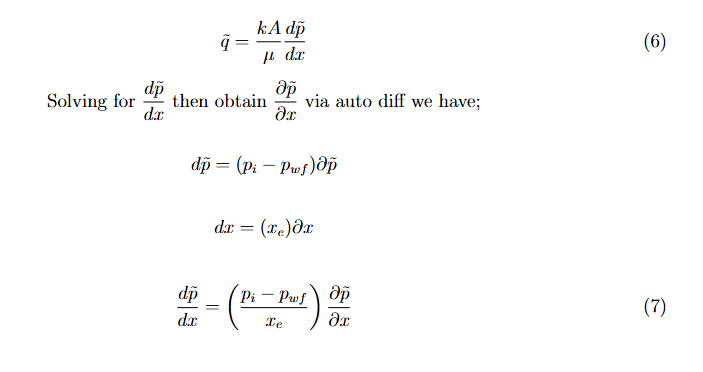

**Extraction of the rates via Automatic differentiation**

In [8]:
t_real_eval = np.linspace(1.0, t_max, 200).reshape(-1, 1)
t_tilde_eval = t_real_eval / t_max #dimensionless time

x_tilde_wellbore = np.zeros_like(t_tilde_eval)
X_wellbore_np = np.hstack((x_tilde_wellbore, t_tilde_eval))

device = next(model.net.parameters()).device
X_tensor = torch.tensor(X_wellbore_np, dtype=torch.float32, requires_grad=True, device=device)

pD_tensor = model.net(X_tensor)
gradients = torch.autograd.grad(
    outputs=pD_tensor,
    inputs=X_tensor,
    grad_outputs=torch.ones_like(pD_tensor),
    create_graph=False
)[0]
grad_pD_tilde = gradients[:, 0:1].cpu().detach().numpy()
grad_p_physical = grad_pD_tilde * ((p_i - p_wf) / x_e)
A_unity = 19.5 
C_metric = 0.08527

q_rate_metric = C_metric * ((k_md * A_unity) / mu) * grad_p_physical
q_rate_stb = q_rate_metric * 6.2898

t_plot = t_real_eval.flatten()
q_plot = q_rate_stb.flatten()



**Rate Visualization plot**

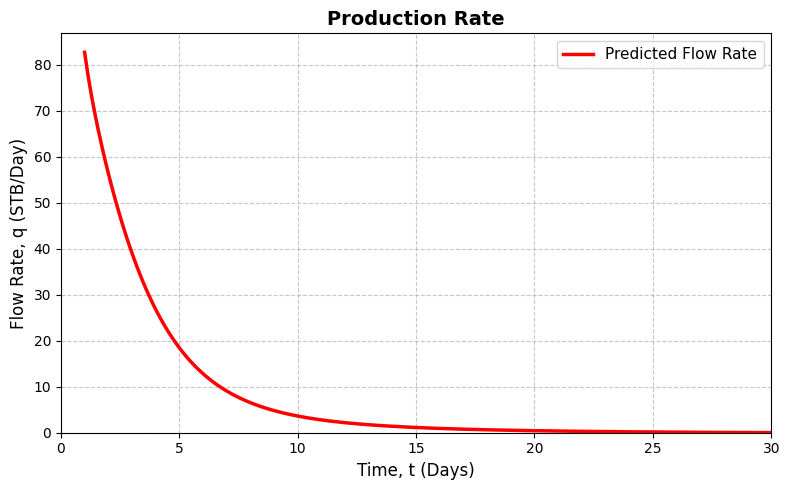

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_plot, q_plot, color='red', linewidth=2.5, label='Predicted Flow Rate')

ax.set_title('Production Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('Time, t (Days)', fontsize=12)
ax.set_ylabel('Flow Rate, q (STB/Day)', fontsize=12)

ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([0, t_max])
ax.set_ylim(bottom=0) 

plt.tight_layout()
plt.show()

## **CASE 1.2: INVOLVING TWO NO FLOW BOUNDARY UTILIZING DOMAIN DECOMPOSITION**

**Reservoir parameters initializations for case 1.2**

In [ ]:
k_md_2 = 120.0
phi_2 = 0.20
mu_2 = 1.0
ct_2 = 1e-5
p_i_2 = 25.0
p_boundary_2 = 3.0

x_min_2 = -500.0
x_max_2 = 750.0
L_2 = x_max_2 - x_min_2

t_max_2 = 30.0
C_constant = 0.000588
eta_2 = C_constant * (k_md_2 / (phi_2 * mu_2 * ct_2)) #The hydraulic diffusivity constant
tD_max_2 = (eta_2 * t_max_2) / (L_2**2)

# Normalized wellbore location inside the [0, 1] grid
x_tilde_well_2 = (0.0 - x_min_2) / L_2




**Setting up the domain for case 1.2 by establishing the left and right boundary for domain decomposition**

In [11]:
timedomain_1_2 = dde.geometry.TimeDomain(0.0, 1.0)

geom_L = dde.geometry.Interval(0.0, x_tilde_well_2) # left boundary for -500m
geom_R = dde.geometry.Interval(x_tilde_well_2, 1.0) # right boundary for +750m

geomtime_L = dde.geometry.GeometryXTime(geom_L, timedomain_1_2)
geomtime_R = dde.geometry.GeometryXTime(geom_R, timedomain_1_2)



**Setting up the dimensionless cartesian PDE from equation 29 for case 1.2**

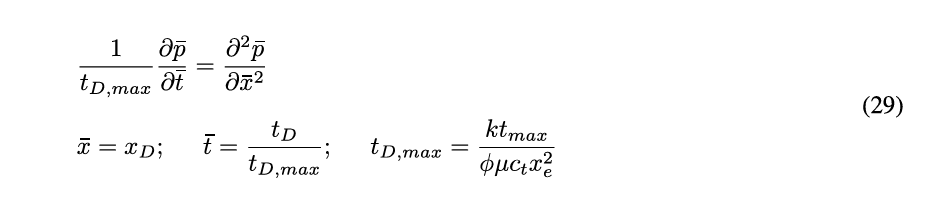

In [12]:
def pde_dimensionless_2(x, pD):
    dpD_dt_tilde = dde.grad.jacobian(pD, x, i=0, j=1)
    d2pD_dx_tilde2 = dde.grad.hessian(pD, x, i=0, j=0)
    residual = (1.0 / tD_max_2) * dpD_dt_tilde - d2pD_dx_tilde2
    return residual

**Setting up the initial and Boundary condition for case 1.2**

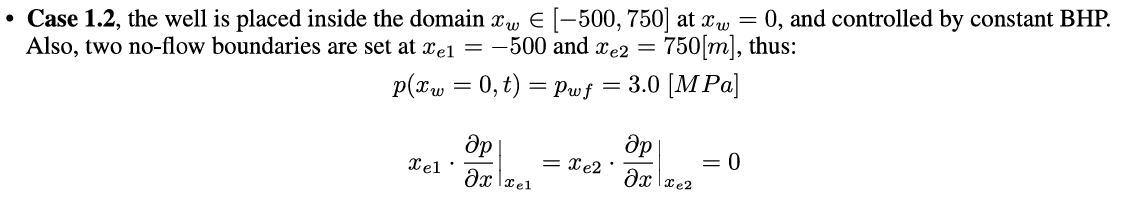

In [13]:
def initial_condition_2(x): return np.ones((len(x), 1))
def no_flow_residual_2(x, pD, _): return dde.grad.jacobian(pD, x, i=0, j=0)

# Left Network BCs
ic_L = dde.icbc.IC(geomtime_L, initial_condition_2, lambda _, on_initial: on_initial)
bc_noflow_left = dde.icbc.OperatorBC(geomtime_L, no_flow_residual_2, lambda x, on_boundary: on_boundary and np.isclose(x[0], 0.0))

# Right Network BCs
ic_R = dde.icbc.IC(geomtime_R, initial_condition_2, lambda _, on_initial: on_initial)
bc_noflow_right = dde.icbc.OperatorBC(geomtime_R, no_flow_residual_2, lambda x, on_boundary: on_boundary and np.isclose(x[0], 1.0))





**Data Object setup using TimePDE, Model Definition and Model Training for case 1.2**

In [14]:
# The Shared Wellbore Constraint using PointSetBC
num_anchors = 500
t_anchors = np.linspace(0.001, 1.0, num_anchors)
x_anchors = np.full(num_anchors, x_tilde_well_2)
anchors_2 = np.column_stack((x_anchors, t_anchors))
pD_target_well_2 = np.zeros((num_anchors, 1))

# Both domains must start and hit 3.0 MPa at x_tilde = 0.4
bc_well_L = dde.icbc.PointSetBC(anchors_2, pD_target_well_2)
bc_well_R = dde.icbc.PointSetBC(anchors_2, pD_target_well_2)

data_L = dde.data.TimePDE(geomtime_L, pde_dimensionless_2, [ic_L, bc_well_L, bc_noflow_left], 
                          num_domain=4000, num_boundary=1000, num_initial=1000, anchors=anchors_2)

data_R = dde.data.TimePDE(geomtime_R, pde_dimensionless_2, [ic_R, bc_well_R, bc_noflow_right], 
                          num_domain=4000, num_boundary=1000, num_initial=1000, anchors=anchors_2)

net_L = dde.nn.FNN([2] + [32] * 4 + [1], "tanh", "Glorot normal")
net_R = dde.nn.FNN([2] + [32] * 4 + [1], "tanh", "Glorot normal")

model_L = dde.Model(data_L, net_L)
model_R = dde.Model(data_R, net_R)

loss_weights_split = [1.0, 2.0, 20.0, 1.0]
print(" TRAINING NETWORK L (LEFT TANK: -500m to 0m)")
model_L.compile("adam", lr=1e-3, loss_weights=loss_weights_split)
model_L.train(iterations=10000)
model_L.compile("L-BFGS")
model_L.train()

print(" TRAINING NETWORK R (RIGHT TANK: 0m to 750m)")
model_R.compile("adam", lr=1e-3, loss_weights=loss_weights_split)
model_R.train(iterations=10000)
model_R.compile("L-BFGS")
model_R.train()

 TRAINING NETWORK L (LEFT TANK: -500m to 0m)
Compiling model...
'compile' took 0.000115 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [1.07e-01, 1.85e+00, 5.93e-01, 3.54e-02]    [1.07e-01, 1.85e+00, 5.93e-01, 3.54e-02]    []  
1000      [9.06e-03, 8.93e-02, 4.84e-02, 1.53e-02]    [9.06e-03, 8.93e-02, 4.84e-02, 1.53e-02]    []  
2000      [7.13e-03, 5.06e-02, 4.08e-02, 8.38e-03]    [7.13e-03, 5.06e-02, 4.08e-02, 8.38e-03]    []  
3000      [3.87e-03, 3.43e-02, 3.51e-02, 1.74e-03]    [3.87e-03, 3.43e-02, 3.51e-02, 1.74e-03]    []  
4000      [2.73e-03, 2.87e-02, 3.09e-02, 6.40e-04]    [2.73e-03, 2.87e-02, 3.09e-02, 6.40e-04]    []  
5000      [3.37e-03, 2.62e-02, 2.81e-02, 3.34e-04]    [3.37e-03, 2.62e-02, 2.81e-02, 3.34e-04]    []  
6000      [6.57e-03, 2.34e-02, 2.70e-02, 3.40e-04]    [6.57e-03, 2.34e-02, 2.70e-02, 3.40e-04]    []  
7000      [1.12e-02, 2.23e-02, 2.53e-02, 4.15e-04]    [1.12

(<deepxde.model.LossHistory at 0x160ae121810>,
 <deepxde.model.TrainState at 0x160ae1216d0>)

**Pressure visualization Plot for case 1.2**

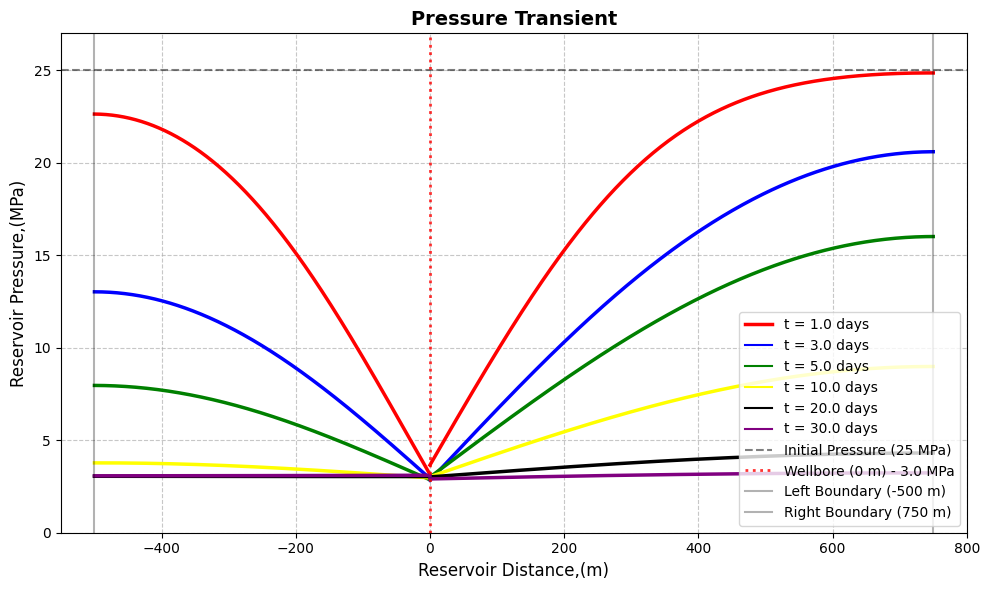

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
# Left Tank: -500m to 0m
x_real_L = np.linspace(x_min_2, 0.0, 400).reshape(-1, 1)
# Right Tank: 0m to 750m
x_real_R = np.linspace(0.0, x_max_2, 400).reshape(-1, 1)

x_tilde_L = (x_real_L - x_min_2) / L_2
x_tilde_R = (x_real_R - x_min_2) / L_2

time_steps_physical_days_2 = [1.0, 3.0, 5.0, 10.0, 20.0, 30.0] 
colors = ['red', 'blue', 'green', 'yellow', 'black','purple']

for idx, t_real in enumerate(time_steps_physical_days_2):
    t_tilde_eval = t_real / t_max_2

    # LEFT TANK
    t_tilde_grid_L = np.full_like(x_tilde_L, t_tilde_eval)
    X_predict_L = np.hstack((x_tilde_L, t_tilde_grid_L))
    pD_predict_L = model_L.predict(X_predict_L)
    p_real_predict_L = pD_predict_L * (p_i_2 - p_boundary_2) + p_boundary_2

    # RIGHT TANK
    t_tilde_grid_R = np.full_like(x_tilde_R, t_tilde_eval)
    X_predict_R = np.hstack((x_tilde_R, t_tilde_grid_R))
    pD_predict_R = model_R.predict(X_predict_R)
    p_real_predict_R = pD_predict_R * (p_i_2 - p_boundary_2) + p_boundary_2

    ax.plot(x_real_L, p_real_predict_L, color=colors[idx], linewidth=2.5, label=f't = {t_real} days' if idx == 0 else "")
    ax.plot(x_real_R, p_real_predict_R, color=colors[idx], linewidth=2.5)

    if idx > 0:
        ax.plot([], [], color=colors[idx], label=f't = {t_real} days')

ax.set_title('Pressure Transient', fontsize=14, fontweight='bold')
ax.set_xlabel('Reservoir Distance,(m)', fontsize=12)
ax.set_ylabel('Reservoir Pressure,(MPa)', fontsize=12)

# Hardcoded physical constraints
ax.axhline(y=p_i_2, color='k', linestyle='--', alpha=0.5, label='Initial Pressure (25 MPa)')
ax.axvline(x=0.0, color='r', linestyle=':', alpha=0.8, linewidth=2, label='Wellbore (0 m) - 3.0 MPa')
ax.axvline(x=x_min_2, color='k', linestyle='-', alpha=0.3, label='Left Boundary (-500 m)')
ax.axvline(x=x_max_2, color='k', linestyle='-', alpha=0.3, label='Right Boundary (750 m)')

ax.legend(loc='lower right', fontsize=10)
ax.grid(True, which='both', linestyle='--', alpha=0.7)

# Buffer the x-axis strictly to the physical domain
ax.set_xlim([x_min_2 - 50, x_max_2 + 50])
ax.set_ylim([0, p_i_2 + 2])

plt.tight_layout()
plt.show()

## **1D INVERSE PROBLEM FOR SECTION 1**

**Setting up the array for the predicted flow rate and introducing noise to it from case 1.1**

In [ ]:
q_array = np.array(q_plot)
print("Clean predicted flowrate:",q_array)

def add_noise(data,noise_type="gaussian", mean=0.0, std=1.0, low=-1.0, high=1.0, seed=None):
        if not isinstance(data, np.ndarray):
                raise TypeError("Input data must be a NumPy array.")
        if data.size == 0:
                raise ValueError("Input array is empty.")
        if noise_type not in ("gaussian"):
                raise ValueError("noise_type must be 'gaussian'.")
        # Setting a seed to enable reproducibility of the noisy array if we had to run the notebook again
        if seed is not None:
            np.random.seed(seed)
        # Adding the noise
        if noise_type == "gaussian":
            noise = np.random.normal(mean, std, data.shape)
        else:
            noise = np.random.uniform(low, high, data.shape)
        
        return data + noise
noisy_q_array = add_noise(q_array, noise_type="gaussian", mean=0, std=2, seed=42)

print("Gaussian noise added:", noisy_q_array)
               

        


Clean predicted flowrate: [8.27389526e+01 7.77066422e+01 7.33216400e+01 6.93664169e+01
 6.57230530e+01 6.23202934e+01 5.91129379e+01 5.60722733e+01
 5.31804695e+01 5.04263382e+01 4.78024368e+01 4.53034668e+01
 4.29248962e+01 4.06625938e+01 3.85124435e+01 3.64703102e+01
 3.45321388e+01 3.26937675e+01 3.09511700e+01 2.93002682e+01
 2.77370949e+01 2.62577877e+01 2.48585567e+01 2.35356236e+01
 2.22853928e+01 2.11043224e+01 1.99889793e+01 1.89360466e+01
 1.79422779e+01 1.70045605e+01 1.61199379e+01 1.52855177e+01
 1.44985523e+01 1.37563858e+01 1.30565138e+01 1.23965464e+01
 1.17741537e+01 1.11872225e+01 1.06336622e+01 1.01115236e+01
 9.61895752e+00 9.15422726e+00 8.71566105e+00 8.30173397e+00
 7.91096544e+00 7.54195166e+00 7.19340658e+00 6.86410570e+00
 6.55289221e+00 6.25868845e+00 5.98046970e+00 5.71728468e+00
 5.46822929e+00 5.23245287e+00 5.00918198e+00 4.79766417e+00
 4.59719896e+00 4.40713501e+00 4.22686529e+00 4.05580854e+00
 3.89341903e+00 3.73920012e+00 3.59266973e+00 3.45338917e+0

**Time step extraction from the rates**

In [11]:
time_step_rates = np.array(t_plot)
dimensionless_time = time_step_rates / t_max
print(dimensionless_time)

[0.03333333 0.03819095 0.04304858 0.0479062  0.05276382 0.05762144
 0.06247906 0.06733668 0.0721943  0.07705193 0.08190955 0.08676717
 0.09162479 0.09648241 0.10134003 0.10619765 0.11105528 0.1159129
 0.12077052 0.12562814 0.13048576 0.13534338 0.14020101 0.14505863
 0.14991625 0.15477387 0.15963149 0.16448911 0.16934673 0.17420436
 0.17906198 0.1839196  0.18877722 0.19363484 0.19849246 0.20335008
 0.20820771 0.21306533 0.21792295 0.22278057 0.22763819 0.23249581
 0.23735343 0.24221106 0.24706868 0.2519263  0.25678392 0.26164154
 0.26649916 0.27135678 0.27621441 0.28107203 0.28592965 0.29078727
 0.29564489 0.30050251 0.30536013 0.31021776 0.31507538 0.319933
 0.32479062 0.32964824 0.33450586 0.33936348 0.34422111 0.34907873
 0.35393635 0.35879397 0.36365159 0.36850921 0.37336683 0.37822446
 0.38308208 0.3879397  0.39279732 0.39765494 0.40251256 0.40737018
 0.41222781 0.41708543 0.42194305 0.42680067 0.43165829 0.43651591
 0.44137353 0.44623116 0.45108878 0.4559464  0.46080402 0.4656616

**Visualization for the noisy production flow rate**

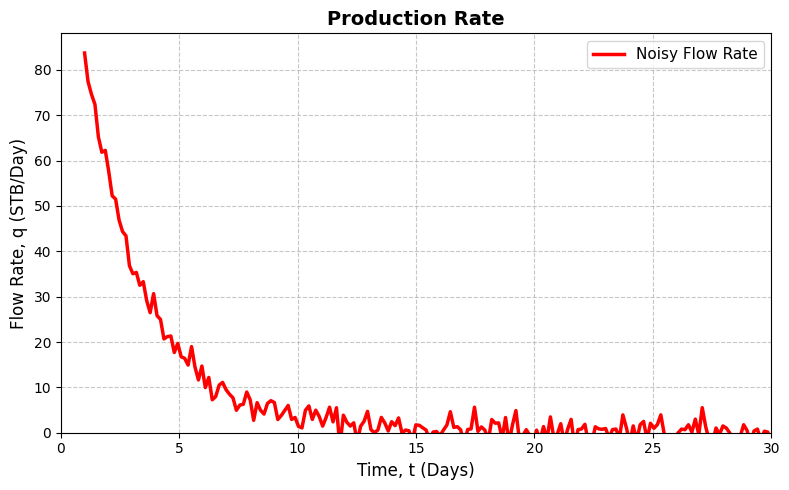

In [12]:
q_plot_noise = noisy_q_array.flatten()

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_plot, q_plot_noise, color='red', linewidth=2.5, label='Noisy Flow Rate')

ax.set_title('Production Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('Time, t (Days)', fontsize=12)
ax.set_ylabel('Flow Rate, q (STB/Day)', fontsize=12)

ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([0, t_max])
ax.set_ylim(bottom=0) 

plt.tight_layout()
plt.show()

# **Defining the Reservoir, fluid properties and initial setup for the inverse problem Inverse problem**

In [ ]:

k_x_max_inverse = 300
x_e_max_inverse = 1000
t_max_inverse = 30

phi_inverse = 0.2
mu_inverse = 1
ct_inverse = 1e-5

C_inverse = 0.000588
eta = C_inverse * (k_x_max_inverse / (phi_inverse * mu_inverse * ct_inverse)) # The hydraulic diffusivity equation

p_i_inverse = 25.0
p_wf_inverse = 3.0


tD_max_inverse = (eta * t_max_inverse) / (x_e_max_inverse**2)
print(tD_max_inverse)

# Initializing the random guesses by setting up a trainable values
eta_k_raw = dde.Variable(0.0) # The permeability
eta_l_raw = dde.Variable(1.0) # The distance away from the boundary from the well

2.6459999999999995


**Setting up the domain for the inverse problem**

In [14]:
geom_1_inverse = dde.geometry.Interval(0.0, 1.0)
timedomain_inverse = dde.geometry.TimeDomain(0.0, 1.0)
geomtime_1_inverse = dde.geometry.GeometryXTime(geom_1_inverse, timedomain_inverse)

# **Setting up the inverse PDE that takes the guessed eta_k and eta_l used for obtaining the unknown parameters**

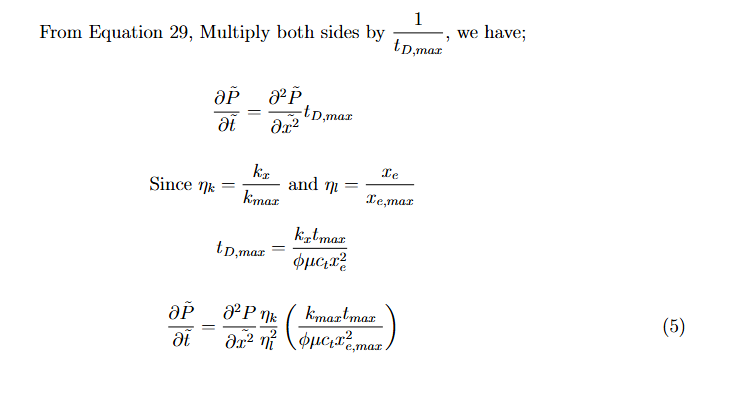

In [15]:

def inverse_pde_dimensionless(x, pD):
    k_frac = 0.05 + 0.95 * torch.sigmoid(eta_k_raw)
    l_frac = 0.10 + 0.90 * torch.sigmoid(eta_l_raw)
    d2pD_dx_tilde2_inverse = dde.grad.hessian(pD, x, i=0, j=0)
    dpD_dt_tilde_inverse = dde.grad.jacobian(pD, x, i=0, j=1)
    residual_inverse = dpD_dt_tilde_inverse - d2pD_dx_tilde2_inverse*(k_frac/l_frac**2)*(tD_max_inverse)
    return residual_inverse

    

**Setting up the initial and boundary conditions of the inverse problem**

In [16]:

def initial_condition_inverse(x):
    return np.ones((len(x), 1))

def pD_wf_func_inverse(x):
    return np.zeros((len(x), 1))

def no_flow_residual_inverse(x, pD, _):
    return dde.grad.jacobian(pD, x, i=0, j=0)

def left_wellbore_inverse(x, on_boundary):
    return on_boundary and np.isclose(x[0], 0.0)

def right_noflow_inverse(x, on_boundary):
    return on_boundary and np.isclose(x[0], 1.0)

ic_inverse = dde.icbc.IC(geomtime_1_inverse, initial_condition_inverse, lambda _, on_initial: on_initial)
bc_well_inverse = dde.icbc.DirichletBC(geomtime_1_inverse, pD_wf_func_inverse, left_wellbore_inverse)
bc_noflow_inverse = dde.icbc.OperatorBC(geomtime_1_inverse, no_flow_residual_inverse, right_noflow_inverse)


**Setting up the data loss constraint for the inputed noisy flowrate, predicted flowrate**

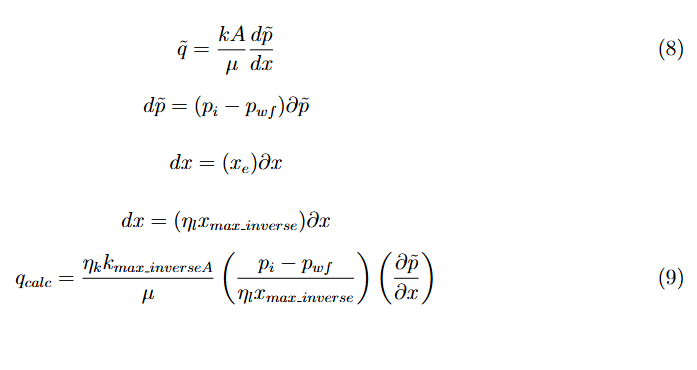

In [17]:

# Knowing the exact time
q_max_val = float(np.max(np.abs(noisy_q_array)))

def darcy_data_loss(x, pD, _):
    k_frac = 0.05 + 0.95 * torch.sigmoid(eta_k_raw)
    l_frac =0.10 + 0.90 * torch.sigmoid(eta_l_raw)
    dpD_dx = dde.grad.jacobian(pD, x, i=0, j=0)

    C_const = 0.08527
    Area = 19.5

    q_calc = C_const*((k_frac*k_x_max_inverse*Area)/(mu_inverse))*((p_i_inverse-p_wf_inverse)/(l_frac*x_e_max_inverse))*(dpD_dx)
    q_calc_stb = q_calc * 6.2898
    
    # looking up the historical noisy data
    t_numpy = x[:, 1:2].detach().cpu().numpy()
    q_target_numpy = np.interp(t_numpy.flatten(), dimensionless_time.flatten(), noisy_q_array.flatten()).reshape(-1, 1)
    q_target_tensor = torch.tensor(q_target_numpy, dtype=torch.float32, device=x.device)

    return (q_calc_stb - q_target_tensor) / q_max_val

bc_data_loss = dde.icbc.OperatorBC(geomtime_1_inverse, darcy_data_loss, left_wellbore_inverse)


**Setting up the Data Object, callbacks and dual training loop**

In [18]:

data_inverse = dde.data.TimePDE(
    geomtime_1_inverse, 
    inverse_pde_dimensionless, 
    [ic_inverse, bc_well_inverse, bc_noflow_inverse, bc_data_loss], 
    num_domain=8000, 
    num_boundary=2000, 
    num_initial=2000
)

net_inverse = dde.nn.FNN([2] + [32] * 4 + [1], "tanh", "Glorot normal")
model_inverse = dde.Model(data_inverse, net_inverse)

# This records eta_k and eta_l every 100 epochs to track convergence
variable_tracker = dde.callbacks.VariableValue(
    [eta_k_raw, eta_l_raw], 
    period=100, 
    filename="inverse_variables_history.dat"
)

loss_weights_inv = [10.0, 2.0, 5.0, 2.0, 10.0]

print("\n INVERSE PROBLEM: PHASE 1 (ADAM)")
model_inverse.compile("adam", lr=1e-3, loss_weights=loss_weights_inv, external_trainable_variables=[eta_k_raw, eta_l_raw])
# Pass the callback to the training loop so it records the history
model_inverse.train(iterations=30000, callbacks=[variable_tracker])

print("\n INVERSE PROBLEM: PHASE 2 (L-BFGS)")
model_inverse.compile("L-BFGS",external_trainable_variables=[eta_k_raw, eta_l_raw])
model_inverse.train(callbacks=[variable_tracker])



 INVERSE PROBLEM: PHASE 1 (ADAM)
Compiling model...
'compile' took 0.000137 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [1.86e+00, 2.02e+00, 2.48e-01, 5.66e-03, 8.51e-01]    [1.86e+00, 2.02e+00, 2.48e-01, 5.66e-03, 8.51e-01]    []  
1000      [8.77e-03, 9.40e-02, 4.14e-02, 2.84e-02, 3.11e-02]    [8.77e-03, 9.40e-02, 4.14e-02, 2.84e-02, 3.11e-02]    []  
2000      [3.32e-03, 5.94e-02, 4.39e-02, 2.42e-02, 1.98e-02]    [3.32e-03, 5.94e-02, 4.39e-02, 2.42e-02, 1.98e-02]    []  
3000      [3.42e-03, 4.99e-02, 4.57e-02, 2.05e-02, 1.83e-02]    [3.42e-03, 4.99e-02, 4.57e-02, 2.05e-02, 1.83e-02]    []  
4000      [1.01e-02, 4.94e-02, 4.41e-02, 1.88e-02, 1.51e-02]    [1.01e-02, 4.94e-02, 4.41e-02, 1.88e-02, 1.51e-02]    []  
5000      [9.92e-03, 4.55e-02, 4.49e-02, 1.73e-02, 1.49e-02]    [9.92e-03, 4.55e-02, 4.49e-02, 1.73e-02, 1.49e-02]    []  
6000      [1.06e-03, 4.14e-02, 4.

(<deepxde.model.LossHistory at 0x1c958150190>,
 <deepxde.model.TrainState at 0x1c958150050>)

**Visualizations for both the Permeability and Distance from the boundary**

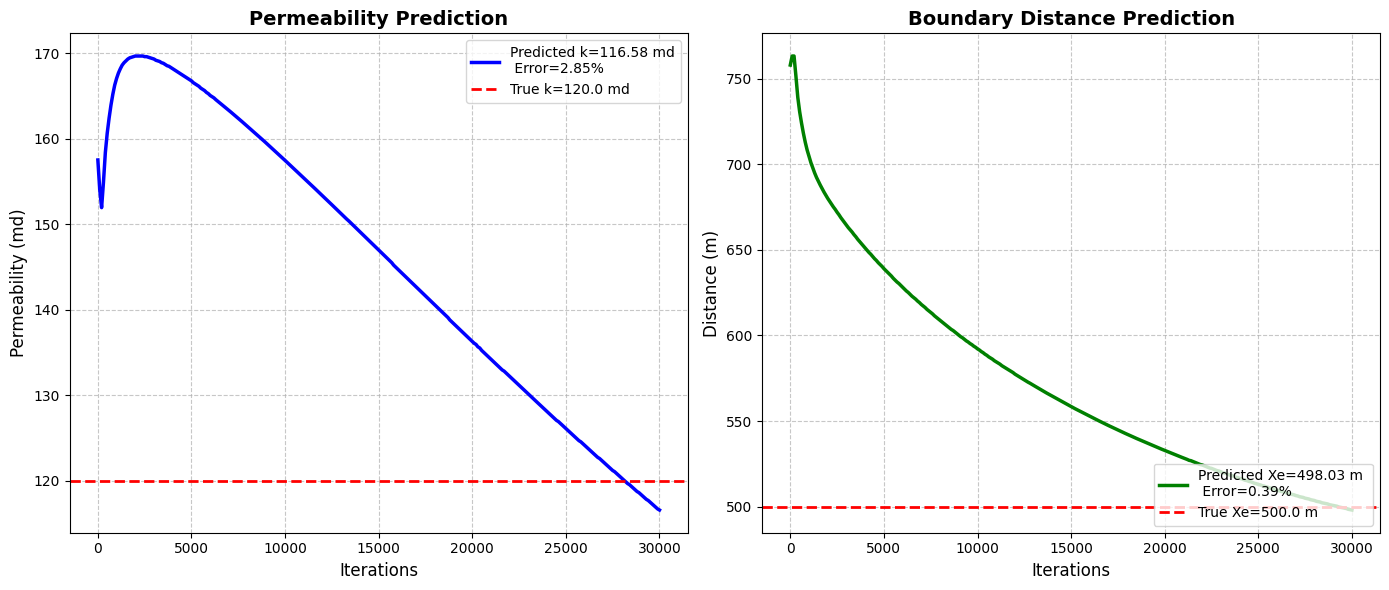

In [20]:

parsed_data = []
with open("inverse_variables_history.dat", "r") as file:
    for line in file:
        # Strip out the brackets and replace commas with spaces
        clean_line = line.replace('[', '').replace(']', '').replace(',', ' ')
        # Split the clean string into pure numbers and convert to float
        values = [float(val) for val in clean_line.split()]
        if values:
            parsed_data.append(values)

history_data = np.array(parsed_data)
steps = history_data[:, 0]
raw_k = history_data[:, 1]
raw_l = history_data[:, 2]

eta_k_history = 0.05 + 0.95 * (1.0 / (1.0 + np.exp(-raw_k)))
eta_l_history = 0.10 + 0.90 * (1.0 / (1.0 + np.exp(-raw_l)))

k_history = eta_k_history * k_x_max_inverse
L_history = eta_l_history * x_e_max_inverse

k_true = 120.0
L_true = 500.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Permeability plot
ax1.plot(steps, k_history, color='blue', linewidth=2.5, label=f'Predicted k={k_history[-1]:.2f} md\n Error={abs((k_true-k_history[-1]) / (k_true)*100):.2f}%')
ax1.axhline(y=k_true, color='r', linestyle='--', linewidth=2, label=f'True k={k_true} md')
ax1.set_title('Permeability Prediction', fontsize=14, fontweight='bold')
ax1.set_xlabel('Iterations', fontsize=12)
ax1.set_ylabel('Permeability (md)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, which='both', linestyle='--', alpha=0.7)

# Plot 2: Boundary Distance plot
ax2.plot(steps, L_history, color='green', linewidth=2.5, label=f'Predicted Xe={L_history[-1]:.2f} m \n Error={abs((L_true-L_history[-1]) / (L_true)*100 ):.2f}%')
ax2.axhline(y=L_true, color='r', linestyle='--', linewidth=2, label=f'True Xe={L_true} m')
ax2.set_title('Boundary Distance Prediction', fontsize=14, fontweight='bold')
ax2.set_xlabel('Iterations', fontsize=12)
ax2.set_ylabel('Distance (m)', fontsize=12)
ax2.legend(loc='lower right')
ax2.grid(True, which='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
 

# **SECTION 2 FORWARD MODEL: USING THE DIMENSIONLESS RADIAL PDE**

**The governing 2D radial Partial Differential Equation for the Diffusivity equation**

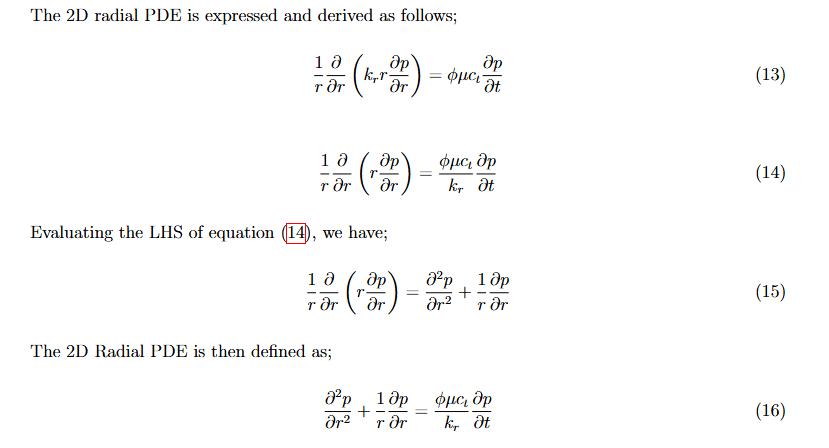

# **CASE 2.1: THE WELL IS PRODUCING AT A CONSTANT BHP**

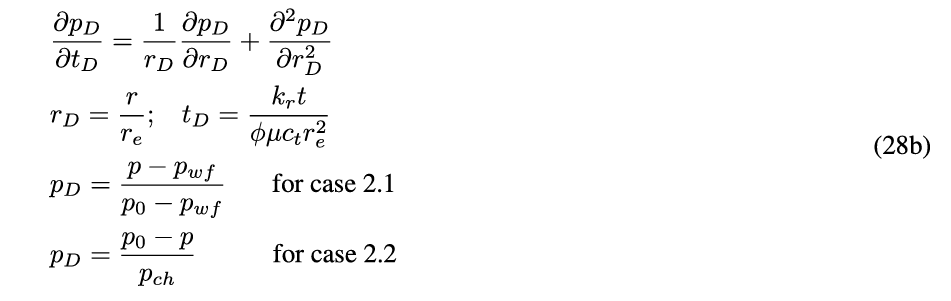

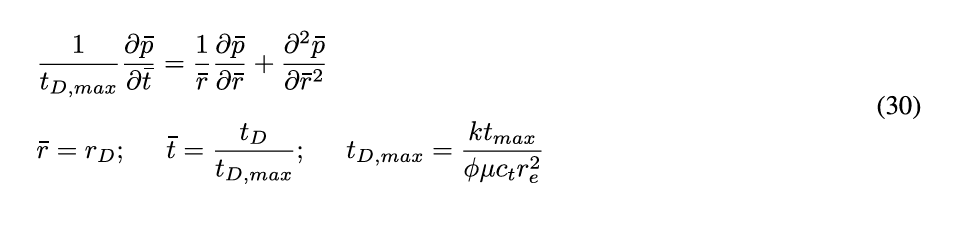

**Reservoir parameters initializations for case 2.1**

In [2]:
r_w = 0.1
r_interface = 50.0
r_e_max = 750
t_max_2_1 = 30

k_md_2_1 = 120.0
phi_2_1 = 0.2
mu_2_1 = 1
ct_2_1 = 1e-5

C_2_1 = 0.000588
eta_2_1 = C_2_1 * (k_md_2_1 / (phi_2_1 * mu_2_1 * ct_2_1)) # The hydraulic diffusivity equation

p_i_2_1 = 25.0
p_wf_2_1 = 3.0

tD_max_2_1 = (eta_2_1 * t_max_2_1) / (r_e_max**2)

r_tilde_well = r_w / r_e_max
r_tilde_interface = r_interface / r_e_max

**The dimesionless space for subdomain 1(Near wellbore zone)**

In [3]:
# Dimensionless radius for subdomain 1
r_grid_1 = np.linspace(r_w, r_interface, 500).reshape(-1, 1)
r_tilde_grid_1 = r_grid_1 / r_e_max

**The dimesionless space for subdomain 2**

In [4]:
# Dimensionless radius for subdomain 2
r_grid_2 = np.linspace(r_interface, r_e_max, 500).reshape(-1, 1)
r_tilde_grid_2 = r_grid_2 / r_e_max

**Setting up the domain for case 2.1 by establishing the multiple domains**

In [5]:
timedomain_2_1 = dde.geometry.TimeDomain(0.0,1.0)
geom_well_interface = dde.geometry.Interval(r_tilde_well,r_tilde_interface) #subdomain 1
geom_interface_boundary = dde.geometry.Interval(r_tilde_interface, 1.0) #subdomain 2 

geom_subdomain1= dde.geometry.GeometryXTime(geom_well_interface,timedomain_2_1)
geom_subdomain2= dde.geometry.GeometryXTime(geom_interface_boundary, timedomain_2_1)

**CPINN Network Architecture**

In [ ]:
class ReservoirCPINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        # Near-Wellbore 
        self.net_near = dde.nn.FNN([2] + [32] * 4 + [1], "tanh", "Glorot normal")
        
        # Outer Reservoir
        self.net_outer = dde.nn.FNN([2] + [32] * 4 + [1], "tanh", "Glorot normal")

        self.regularizer = None 
        self._input_transform = None
        self._output_transform = None
        
    def forward(self, x):
        p_near = self.net_near(x)
        p_outer = self.net_outer(x)
        return torch.cat((p_near, p_outer), dim=1)

net_cpinn = ReservoirCPINN()

**Setting up the conservative PINNs constraints for connecting domain1 and domain2 together for case 2.1**

In [ ]:
def pressure_continuity(x, y, _):
    p1 = y[:, 0:1] # Subdomain 1 prediction
    p2 = y[:, 1:2] # Subdomain 2 prediction
    
    return p1 - p2

def flux_continuity(x, y, _):
    dp1_dr = dde.grad.jacobian(y, x, i=0, j=0) 
    
    dp2_dr = dde.grad.jacobian(y, x, i=1, j=0) 
    
    return dp1_dr - dp2_dr


def on_interface(x, on_boundary):
    return dde.utils.isclose(x[0], r_tilde_interface)


bc_pressure_cont = dde.icbc.OperatorBC(
    geom_subdomain1,
    pressure_continuity, 
    on_interface
)

bc_flux_cont = dde.icbc.OperatorBC(
    geom_subdomain1, 
    flux_continuity, 
    on_interface
)

**Setting up the initial conditions for the domains**

In [8]:
def initial_condition_2_1(x):
    return np.ones((len(x), 1))

ic_subdomain1 = dde.icbc.IC(geom_subdomain1, initial_condition_2_1, lambda _, on_initial: on_initial,component=0)
ic_subdomain2 = dde.icbc.IC(geom_subdomain2, initial_condition_2_1, lambda _, on_initial: on_initial,component=1)

**Setting up the wellbore boundary condition**

In [9]:

def pD_wf_func_2_1(x):
    return np.zeros((len(x), 1))

def well_boundary_2_1(x, on_boundary):
    return on_boundary and np.isclose(x[0], r_tilde_well)

bc_well_2_1 = dde.icbc.DirichletBC(geom_subdomain1, pD_wf_func_2_1, well_boundary_2_1, component=0)


**Setting up the no flow outer boundary**

In [10]:
def no_flow_residual_2_1(x, pD, _):
    dpD_dr_tilde = dde.grad.jacobian(pD, x, i=1, j=0)
    return dpD_dr_tilde

def no_flow_boundary_2_1(x, on_boundary):
    return on_boundary and np.isclose(x[0], 1.0)

bc_noflow = dde.icbc.OperatorBC(geom_subdomain2, no_flow_residual_2_1, no_flow_boundary_2_1)

**Setting up the PDE for section 2.1 using equation 30**

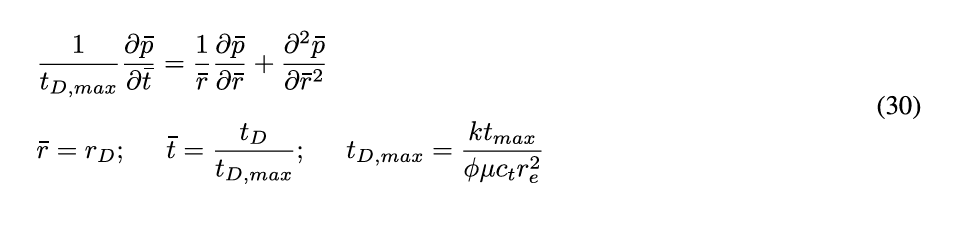

In [ ]:
def pde_dimensionless_2_1(x, y):
    r_D = x[:, 0:1] 
    
    mask_1 = torch.where(r_D <= r_tilde_interface, torch.ones_like(r_D), torch.zeros_like(r_D)).detach()
    mask_2 = torch.where(r_D >= r_tilde_interface, torch.ones_like(r_D), torch.zeros_like(r_D)).detach()
    
    # SUBDOMAIN 1
    dp1_dr = dde.grad.jacobian(y, x, i=0, j=0)
    dp1_dt = dde.grad.jacobian(y, x, i=0, j=1)
    d2p1_dr2 = dde.grad.hessian(y, x, component=0, i=0, j=0)
    
    residual_1 = mask_1 * (r_D * (1/tD_max_2_1)*dp1_dt - dp1_dr - r_D * d2p1_dr2)

    #  SUBDOMAIN 2
    dp2_dr = dde.grad.jacobian(y, x, i=1, j=0)
    dp2_dt = dde.grad.jacobian(y, x, i=1, j=1)
    d2p2_dr2 = dde.grad.hessian(y, x, component=1, i=0, j=0)
    
    residual_2 = mask_2 * (r_D * (1/tD_max_2_1)*dp2_dt - dp2_dr - r_D * d2p2_dr2)

    return [residual_1, residual_2]

**Data Object setup using TimePDE, Model Definition and Model Training for case 2.1**

In [ ]:
bcs_and_ics = [
    ic_subdomain1,     
    ic_subdomain2,    
    bc_well_2_1,       
    bc_noflow,         
    bc_pressure_cont, 
    bc_flux_cont      
]
loss_weights_2_1 = [1, 1, 10, 10, 500, 10, 100, 100]


# Define the Global Geometry
geom_global = dde.geometry.GeometryXTime(
    dde.geometry.Interval(r_tilde_well, 1.0), timedomain_2_1
)

t_anchors = np.linspace(0, 1.0, 800).reshape(-1, 1)

# Interface Anchors (r = 50m)
r_int_anchors = np.full_like(t_anchors, r_tilde_interface)
interface_pts = np.hstack((r_int_anchors, t_anchors))

# Wellbore Anchors (r = 0.1m)
r_w_anchors = np.full_like(t_anchors, r_tilde_well)
wellbore_pts = np.hstack((r_w_anchors, t_anchors))

# Initial Condition Anchors (t = 0, across the whole reservoir)
r_ic_anchors = np.linspace(r_tilde_well, 1.0, 800).reshape(-1, 1)
t_ic_anchors = np.zeros_like(r_ic_anchors)
ic_pts = np.hstack((r_ic_anchors, t_ic_anchors))

all_anchors = np.vstack((interface_pts, wellbore_pts, ic_pts))

# 5. Compile the Data Object
data_2_1 = dde.data.TimePDE(
    geometryxtime=geom_global,
    pde=pde_dimensionless_2_1,
    ic_bcs=bcs_and_ics,
    num_domain=3000,   
    num_boundary=800, 
    num_initial=800,
    anchors=all_anchors 
)

# 3. Model Definition
model_2_1 = dde.Model(data_2_1, net_cpinn)

resampler = dde.callbacks.PDEPointResampler(period=5000) 


model_2_1.compile(
    "adam", 
    lr=1e-3, 
    loss_weights=loss_weights_2_1,
    decay=("step", 10000, 0.1) 
)

# Run the unified model
losshistory, train_state = model_2_1.train(
    iterations=20000, 
    callbacks=[resampler]
)

Compiling model...
'compile' took 1.015732 s

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric
0         [5.50e-02, 1.09e-01, 1.46e+01, 1.59e+01, 1.53e+01, 1.25e+00, 1.35e+00, 1.77e+00]    [5.50e-02, 1.09e-01, 1.46e+01, 1.59e+01, 1.53e+01, 1.25e+00, 1.35e+00, 1.77e+00]    []  
1000      [5.96e-01, 1.72e-01, 7.48e-01, 3.79e-01, 1.94e-01, 3.75e-02, 1.23e-01, 2.86e-03]    [5.96e-01, 1.72e-01, 7.48e-01, 3.79e-01, 1.94e-01, 3.75e-02, 1.23e-01, 2.86e-03]    []  
2000      [4.30e-01, 1.62e-01, 5.09e-01, 1.73e-01, 2.12e-01, 7.37e-03, 9.61e-02, 2.34e-03]    [4.30e-01, 1.62e-01, 5.09e-01, 1.73e-01, 2.12e-01, 7.37e-03, 9.61e-02, 2.34e-03]    []  
3000      [3.83e-01, 1.81e-01, 3.78e-01, 1.11e-01, 2.33e-01, 9.52e-03, 7.39e-02, 6.59e-04]    [3.83e-01, 1.81e-01, 3.78e-01, 1.11e-01, 2.33e-01, 9.52e-03, 7.39e-02, 6.59e-04]    []  
4000      [3.

**Visualization for Section 2 pressure transient**

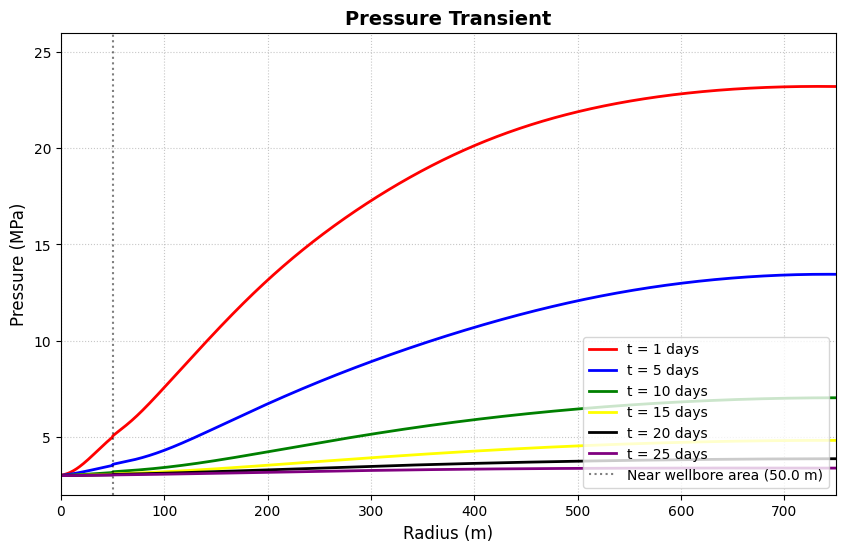

In [18]:
target_days = [1, 5, 10, 15, 20, 25]
colors = ['red', 'blue', 'green', 'yellow', 'black', 'purple']

r_eval = np.linspace(r_w, r_e_max, 1000)
r_tilde_eval = r_eval / r_e_max

plt.figure(figsize=(10, 6))

for day, color in zip(target_days, colors):
    t_tau = day / t_max_2_1 
    
    # 2. Create the (r_tilde, tau) coordinate pairs
    t_eval = np.full_like(r_tilde_eval, t_tau)
    X_pred = np.hstack((r_tilde_eval.reshape(-1, 1), t_eval.reshape(-1, 1)))
    
    y_pred = model_2_1.predict(X_pred)
    
    pD_pred = np.zeros_like(r_tilde_eval)
    for i, r in enumerate(r_eval):
        if r <= r_interface:
            pD_pred[i] = y_pred[i, 0] # Subdomain 1
        else:
            pD_pred[i] = y_pred[i, 1] # Subdomain 2
            
    p_real = p_wf_2_1 + pD_pred * (p_i_2_1 - p_wf_2_1)
    
    plt.plot(r_eval, p_real, color=color, linewidth=2, label=f't = {day} days')
    
plt.axvline(x=r_interface, color='k', linestyle=':', alpha=0.5, label=f'Near wellbore area ({r_interface} m)')
plt.title("Pressure Transient", fontsize=14, fontweight='bold')
plt.xlabel("Radius (m)", fontsize=12)
plt.ylabel("Pressure (MPa)", fontsize=12)
plt.xlim(0, r_e_max)
plt.ylim(p_wf_2_1 - 1, p_i_2_1 + 1)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

**Setting up the rate**

In [15]:
t_real_eval_2_1 = np.linspace(1.0, t_max_2_1, 200).reshape(-1, 1)
t_tilde_eval_2_1 = t_real_eval_2_1 / t_max_2_1 #dimensionless time

r_tilde_wellbore = np.zeros_like(t_tilde_eval_2_1)
R_wellbore_np = np.hstack((r_tilde_wellbore, t_tilde_eval_2_1))

device = next(model_2_1.net.parameters()).device
R_tensor = torch.tensor(R_wellbore_np, dtype=torch.float32, requires_grad=True, device=device)

pD_tensor_2_1 = model_2_1.net(R_tensor)
gradients_2_1 = torch.autograd.grad(
    outputs=pD_tensor_2_1,
    inputs=R_tensor,
    grad_outputs=torch.ones_like(pD_tensor_2_1),
    create_graph=False
)[0]
grad_pD_tilde_2_1 = gradients_2_1[:, 0:1].cpu().detach().numpy()
grad_p_physical_2_1 = grad_pD_tilde_2_1 * ((p_i_2_1 - p_wf_2_1) / r_e_max)
A_unity_2_1 = 19.5 
C_metric_2_1 = 0.08527

q_rate_metric_2_1 = C_metric_2_1 * ((k_md_2_1 * A_unity_2_1) / mu_2_1) * grad_p_physical_2_1
q_rate_stb_2_1 = q_rate_metric_2_1 * 6.2898

t_plot_2_1 = t_real_eval_2_1.flatten()
q_plot_2_1 = q_rate_stb_2_1.flatten()



**Visualization for the rate**

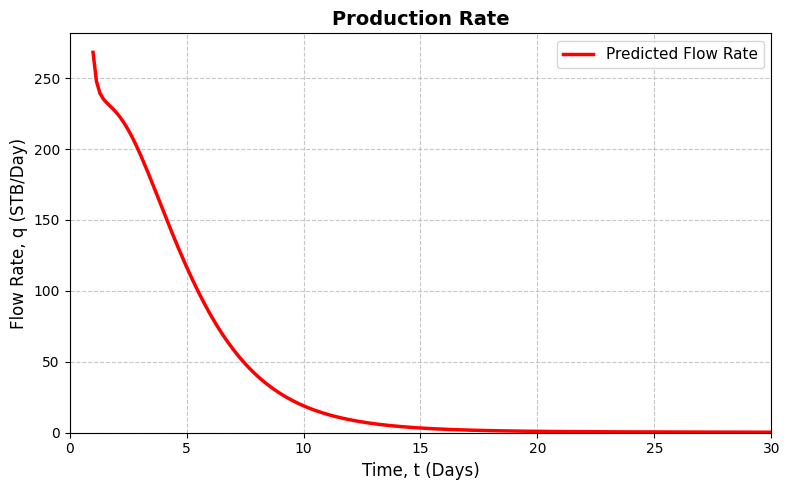

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_plot_2_1, q_plot_2_1, color='red', linewidth=2.5, label='Predicted Flow Rate')

ax.set_title('Production Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('Time, t (Days)', fontsize=12)
ax.set_ylabel('Flow Rate, q (STB/Day)', fontsize=12)

ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([0, t_max_2_1])
ax.set_ylim(bottom=0) 

plt.tight_layout()
plt.show()

# **CASE 2.2: THE WELL IS PRODUCING AT A CONSTANT RATE**

In [2]:
r_w_2_2 = 0.1
r_interface_2_2 = 50.0
r_e_max_2_2 = 750
t_max_2_2 = 30

k_md_2_2 = 120.0
phi_2_2 = 0.2
mu_2_2 = 1
ct_2_2 = 1e-5

C_2_2 = 0.000588
eta_2_2 = C_2_2 * (k_md_2_2 / (phi_2_2 * mu_2_2 * ct_2_2)) # The hydraulic diffusivity equation

p_i_2_2 = 25.0
p_wf_2_2 = 3.0

tD_max_2_2 = (eta_2_2 * t_max_2_2) / (r_e_max_2_2**2)

r_tilde_well_2 = r_w_2_2 / r_e_max_2_2
r_tilde_interface_2 = r_interface_2_2 / r_e_max_2_2

**Setting up the characteristics pressure**

In [3]:
q_w = 250
h = 50

p_ch = (q_w*mu_2_2)/(2*np.pi*k_md_2_2*h)
pressure_char = p_ch/r_w_2_2

**Setting up the domain for the case 2.2**

In [4]:
timedomain_2_2 = dde.geometry.TimeDomain(0.0,1.0)
geom_well_interface_2 = dde.geometry.Interval(r_tilde_well_2,r_tilde_interface_2) #subdomain 1
geom_interface_boundary_2 = dde.geometry.Interval(r_tilde_interface_2, 1.0) #subdomain 2 

geom_subdomain_1= dde.geometry.GeometryXTime(geom_well_interface_2,timedomain_2_2)
geom_subdomain_2= dde.geometry.GeometryXTime(geom_interface_boundary_2, timedomain_2_2)

**Setting up the CPINN Architecture**

In [ ]:
class ReservoirCPINN_2(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        # Near-Wellbore 
        self.net_near = dde.nn.FNN([2] + [32] * 4 + [1], "tanh", "Glorot normal")
        
        # Outer Reservoir
        self.net_outer = dde.nn.FNN([2] + [32] * 4 + [1], "tanh", "Glorot normal")

        self.regularizer = None 
        self._input_transform = None
        self._output_transform = None
        
    def forward(self, x):
        r_tilde = x[:, 0:1]
        
        # Raw network predictions
        p_near_raw = self.net_near(x)
        p_outer_raw = self.net_outer(x)
        
        log_term = -torch.log(r_tilde)
        
        p_near = p_near_raw + log_term
        p_outer = p_outer_raw + log_term
        
        return torch.cat((p_near, p_outer), dim=1)

net_cpinn_2 =ReservoirCPINN_2()

**Setting up the conservative PINNs constraints for connecting domain1 and domain2 together for case 2.2**

In [ ]:
def pressure_continuity_2(x, y, _):
    p1 = y[:, 0:1] # Subdomain 1 prediction
    p2 = y[:, 1:2] # Subdomain 2 prediction
    
    return p1 - p2

def flux_continuity_2(x, y, _):
    dp1_dr = dde.grad.jacobian(y, x, i=0, j=0) 
    
    dp2_dr = dde.grad.jacobian(y, x, i=1, j=0) 
    
    return dp1_dr - dp2_dr


def on_interface_2(x, on_boundary):
    return dde.utils.isclose(x[0], r_tilde_interface_2)


bc_pressure_cont_2 = dde.icbc.OperatorBC(
    geom_subdomain_1,
    pressure_continuity_2, 
    on_interface_2
)

bc_flux_cont_2 = dde.icbc.OperatorBC(
    geom_subdomain_2, 
    flux_continuity_2, 
    on_interface_2
)

**Setting up the intiail condition**

In [7]:
def initial_condition_2_2(x):
    return np.zeros((len(x), 1))

ic_subdomain_1 = dde.icbc.IC(geom_subdomain_1, initial_condition_2_2, lambda _, on_initial: on_initial,component=0)
ic_subdomain_2 = dde.icbc.IC(geom_subdomain_2, initial_condition_2_2, lambda _, on_initial: on_initial,component=1)

**Setting up the well boundary conditions**

In [8]:

def constant_rate(x, pD,_):
    dpD_dr = dde.grad.jacobian(pD,x, i=0,j=0)
    residual = (r_w_2_2 / r_e_max_2_2) * dpD_dr + 1.0
    return residual

def well_boundary_2_2(x, on_boundary):
    return on_boundary and np.isclose(x[0], r_tilde_well_2)

bc_well_2_2 = dde.icbc.OperatorBC(geom_subdomain_1, constant_rate, well_boundary_2_2)

**Setting up the no-flow boundary conditions**

In [9]:
def no_flow_residual_2_2(x, pD, _):
    dpD_dr_tilde = dde.grad.jacobian(pD, x, i=1, j=0)
    return dpD_dr_tilde

def no_flow_boundary_2_2(x, on_boundary):
    return on_boundary and np.isclose(x[0], 1.0)

bc_noflow_2_2 = dde.icbc.OperatorBC(geom_subdomain_2, no_flow_residual_2_2, no_flow_boundary_2_2)

**Setting up the PDE**

In [ ]:
def pde_dimensionless_2_2(x, y):
    r_D = x[:, 0:1] 
    
    mask_1 = torch.where(r_D <= r_tilde_interface_2, torch.ones_like(r_D), torch.zeros_like(r_D)).detach()
    mask_2 = torch.where(r_D >= r_tilde_interface_2, torch.ones_like(r_D), torch.zeros_like(r_D)).detach()
    
    #  SUBDOMAIN 1
    dp1_dr = dde.grad.jacobian(y, x, i=0, j=0)
    dp1_dt = dde.grad.jacobian(y, x, i=0, j=1)
    d2p1_dr2 = dde.grad.hessian(y, x, component=0, i=0, j=0)
    
    residual_1 = mask_1 * (r_D * (1/tD_max_2_2)*dp1_dt - dp1_dr - r_D * d2p1_dr2)

    # SUBDOMAIN 2
    dp2_dr = dde.grad.jacobian(y, x, i=1, j=0)
    dp2_dt = dde.grad.jacobian(y, x, i=1, j=1)
    d2p2_dr2 = dde.grad.hessian(y, x, component=1, i=0, j=0)
    
    residual_2 = mask_2 * (r_D * (1/tD_max_2_2)*dp2_dt - dp2_dr - r_D * d2p2_dr2)

    return [residual_1, residual_2]

**Data Object setup using TimePDE, Model Definition and Model Training for case 2.2**

In [ ]:
bcs_and_ics_2 = [
    ic_subdomain_1,     
    ic_subdomain_2,     
    bc_well_2_2,        
    bc_noflow_2_2,       
    bc_pressure_cont_2,  
    bc_flux_cont_2      
]
loss_weights_2_2 = [1, 1, 10, 10, 500, 10, 100, 100]

# 3. Define the Global Geometry
geom_global_2 = dde.geometry.GeometryXTime(
    dde.geometry.Interval(r_tilde_well_2, 1.0), timedomain_2_2
)

t_anchors_2 = np.linspace(0, 1.0, 800).reshape(-1, 1)

# Interface Anchors (r = 50m)
r_int_anchors_2 = np.full_like(t_anchors_2, r_tilde_interface_2)
interface_pts_2 = np.hstack((r_int_anchors_2, t_anchors_2))

#  Wellbore Anchors (r = 0.1m) 
r_w_anchors_2 = np.full_like(t_anchors_2, r_tilde_well_2)
wellbore_pts_2 = np.hstack((r_w_anchors_2, t_anchors_2))

# Initial Condition Anchors (t = 0)
r_ic_anchors_2 = np.linspace(r_tilde_well_2, 1.0, 800).reshape(-1, 1)
t_ic_anchors_2 = np.zeros_like(r_ic_anchors_2)
ic_pts_2 = np.hstack((r_ic_anchors_2, t_ic_anchors_2))

all_anchors_2 = np.vstack((interface_pts_2, wellbore_pts_2, ic_pts_2))

data_2_2 = dde.data.TimePDE(
    geometryxtime=geom_global_2,
    pde=pde_dimensionless_2_2,
    ic_bcs=bcs_and_ics_2,
    num_domain=3000,   
    num_boundary=800, 
    num_initial=800,
    anchors=all_anchors_2 
)

model_2_2 = dde.Model(data_2_2, net_cpinn_2)

resampler_2 = dde.callbacks.PDEPointResampler(period=5000) 

model_2_2.compile(
    "adam", 
    lr=1e-3, 
    loss_weights=loss_weights_2_2,
    decay=("step", 10000, 0.1) 
)

losshistory_2, train_state_2 = model_2_2.train(
    iterations=20000, 
    callbacks=[resampler_2]
)

Compiling model...
'compile' took 0.971124 s

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric
0         [1.45e-04, 2.03e-02, 2.07e+01, 2.17e+01, 1.65e-09, 7.76e+00, 7.47e+00, 4.59e+00]    [1.45e-04, 2.03e-02, 2.07e+01, 2.17e+01, 1.65e-09, 7.76e+00, 7.47e+00, 4.59e+00]    []  
1000      [9.29e-01, 5.90e-01, 1.45e+00, 1.66e+00, 1.39e-05, 5.96e-02, 3.39e-02, 5.55e-03]    [9.29e-01, 5.90e-01, 1.45e+00, 1.66e+00, 1.39e-05, 5.96e-02, 3.39e-02, 5.55e-03]    []  
2000      [8.53e-01, 1.81e-01, 1.16e+00, 1.37e+00, 8.08e-06, 3.93e-03, 5.53e-02, 1.22e-02]    [8.53e-01, 1.81e-01, 1.16e+00, 1.37e+00, 8.08e-06, 3.93e-03, 5.53e-02, 1.22e-02]    []  
3000      [6.98e-01, 6.08e-02, 1.06e+00, 1.20e+00, 4.94e-06, 1.05e-02, 3.89e-02, 3.13e-02]    [6.98e-01, 6.08e-02, 1.06e+00, 1.20e+00, 4.94e-06, 1.05e-02, 3.89e-02, 3.13e-02]    []  
4000      [4.

**Visualization for the constant rate case 2.2**

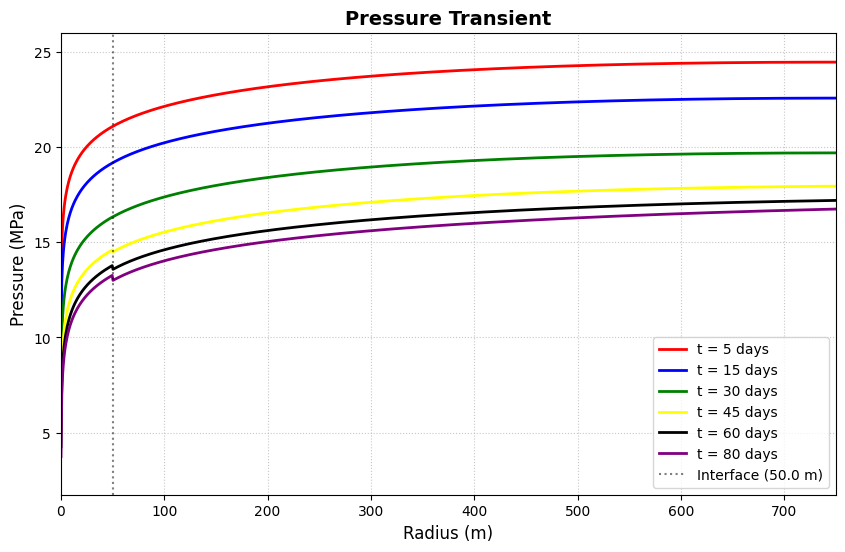

In [31]:
q_w_heavy = 5000

p_ch_metric = 1.842 * (q_w_heavy * mu_2_2) / (k_md_2_2 * h)

target_days_2 = [5, 15, 30, 45, 60, 80]
colors_2 = ['red', 'blue', 'green', 'yellow', 'black', 'purple']

r_eval_2 = np.linspace(r_w_2_2, r_e_max_2_2, 1000)
r_tilde_eval_2 = r_eval_2 / r_e_max_2_2

plt.figure(figsize=(10, 6))

for day, color in zip(target_days_2, colors_2):
    t_tau_2 = day / t_max_2_2 
    
    t_eval_2 = np.full_like(r_tilde_eval_2, t_tau_2)
    X_pred_2 = np.hstack((r_tilde_eval_2.reshape(-1, 1), t_eval_2.reshape(-1, 1)))
    
    y_pred_2 = model_2_2.predict(X_pred_2)
    
    pD_pred_2 = np.zeros_like(r_tilde_eval_2)
    for i, r in enumerate(r_eval_2):
        if r <= r_interface_2_2:
            pD_pred_2[i] = y_pred_2[i, 0] 
        else:
            pD_pred_2[i] = y_pred_2[i, 1] 
            
    p_real_2 = p_i_2_2 - (pD_pred_2 * p_ch_metric)
    
    plt.plot(r_eval_2, p_real_2, color=color, linewidth=2, label=f't = {day} days')
    
plt.axvline(x=r_interface_2_2, color='k', linestyle=':', alpha=0.5, label=f'Interface ({r_interface_2_2} m)')
plt.title(f"Pressure Transient", fontsize=14, fontweight='bold')
plt.xlabel("Radius (m)", fontsize=12)
plt.ylabel("Pressure (MPa)", fontsize=12)
plt.xlim(0, r_e_max_2_2)

plt.ylim(p_i_2_2 - (np.max(pD_pred_2) * p_ch_metric) - 2, p_i_2_2 + 1) 

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right')
plt.show()